# TTFM Inference Quick Start

This notebook loads the TTFM pipeline from the Hugging Face Hub and runs a forecast on a sample CSV. Pre-trained weights are at [bekzatajan/ttfm](https://huggingface.co/bekzatajan/ttfm/tree/main). Prepared FNSPID data (CSVs and pre-computed summaries) is available at [bekzatajan/fnspid](https://huggingface.co/datasets/bekzatajan/fnspid) — download with `uv run python scripts/download_fnspid.py --all`.

**Requirements:** Install the package from the repo root (`uv sync`). A vLLM server must be running and `VLLM_BASE_URL` / `VLLM_MODEL` set (default URL: http://localhost:8004/v1, default model: openai/gpt-oss-120b); alternatively you can pass pre-computed `summaries` to `predict()` to skip LLM calls entirely (see example below).

**Evaluation workflows:** For batch evaluation, use `python -m ttfmeval.evaluation` (full eval with baselines) or `python scripts/eval_simple.py` (lightweight eval from pre-cached summaries). You can use pre-computed summaries from the HF dataset or generate your own with `--cache_summaries`.

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore", message="IProgress not found")

import numpy as np
import pandas as pd
from ttfmeval import TTFMPipeline

pipeline = TTFMPipeline.from_pretrained(
    "bekzatajan/ttfm",
    device="cuda",  # or "cpu"
)

Loading Chronos-2 on device: cuda
Loading TimesFM 2.5...
Downloaded.
Compiling model...
TimesFM 2.5 loaded
Initialized univariate models: chronos, timesfm (prophet on-demand)


## Load sample data

Load a local CSV with columns `t`, `y_t`, `text`. We use the first `seq_len` rows as context for one prediction. To download prepared FNSPID CSVs, run `uv run python scripts/download_fnspid.py --csvs` (see README).

In [2]:
seq_len = 384
pred_len = 16

# Load a prepared FNSPID CSV (download first: uv run python scripts/download_fnspid.py --csvs)
csv_path = "../data/fnspid_prepared/fnspid_0.5_complement_csvs/adbe_with_text.csv"  # adjust path
df = pd.read_csv(csv_path)

forecast = pipeline.predict_from_dataframe(df, pred_len=pred_len, seq_len=seq_len)
print(f"Forecast shape: {forecast.shape}")  # (pred_len,)

Forecast shape: (16,)


## Plot context and forecast

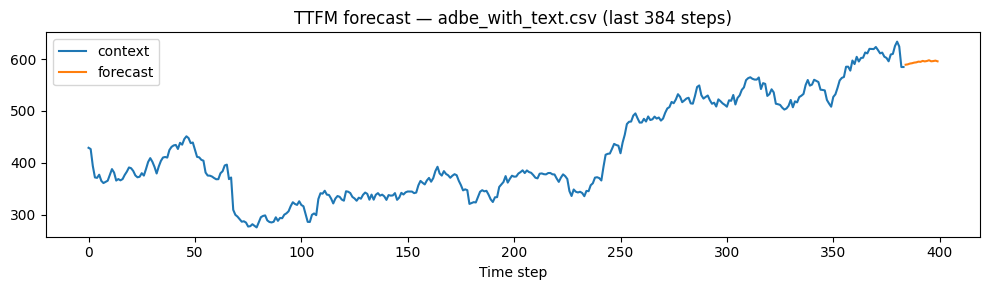

In [3]:
import matplotlib.pyplot as plt

ctx = df.tail(seq_len)["y_t"].values

plt.figure(figsize=(10, 3))
plt.plot(np.arange(len(ctx)), ctx, label="context")
plt.plot(np.arange(len(ctx), len(ctx) + pred_len), forecast, label="forecast")
plt.legend()
plt.xlabel("Time step")
plt.title("TTFM forecast — adbe_with_text.csv (last {} steps)".format(seq_len))
plt.tight_layout()
plt.show()

## Using pre-computed summaries (optional, no LLM server needed)

If you downloaded pre-computed summaries from the [bekzatajan/fnspid](https://huggingface.co/datasets/bekzatajan/fnspid) dataset (`uv run python scripts/download_fnspid.py --summaries`), you can pass them to `predict()` to skip LLM generation entirely. Each summary is a single string per sample in the batch.

In [4]:
import json, os

# Point to the summaries directory for this dataset
summaries_dir = "../data/fnspid_prepared/fnspid_0.5_complement/adbe_with_text"  # adjust path
summary_path = os.path.join(summaries_dir, "summary_0.json")

with open(summary_path) as f:
    summary_data = json.load(f)

print(f"Summary preview: {summary_data['summary'][:200]}...")

# Pass the pre-computed summary — skips LLM generation, text is not needed
forecast_with_summary = pipeline.predict_from_dataframe(
    df, pred_len=pred_len, seq_len=seq_len,
    summaries=[summary_data["summary"]],
)
print(f"Forecast shape: {forecast_with_summary.shape}")  # (pred_len,)

Summary preview: **FACTUAL SUMMARY:**  
Across the 32 timesteps the series has risen steadily from 0.6657 to 2.3540, reflecting a strong upward momentum that coincides with repeated positive news for Adobe (robust ear...
Forecast shape: (16,)
